In [1]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

# !pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

import torch
from torch_geometric.datasets import TUDataset

dataset = TUDataset(root=r'D:\Orbit_degree_LP\jia\SI\IMDB-MULTI', name='IMDB-MULTI')
# - root (str) – Root directory where the dataset should be saved.（保存的路径）
# - name (str) – The name of the dataset.（名字）

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0] 

print()
print(data)
print('=============================================================')

print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

2.9.1+cpu


Processing...



Dataset: IMDB-MULTI(1500):
Number of graphs: 1500
Number of features: 0
Number of classes: 3

Data(edge_index=[2, 42], y=[1], num_nodes=7)
Number of nodes: 7
Number of edges: 42
Average node degree: 6.00
Has isolated nodes: False
Has self-loops: False
Is undirected: True


Done!


In [ ]:
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx
import networkx as nx
import pandas as pd
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import os
from find_motifs import * 
from Motif_structures_1216 import * 
print("正在初始化轨道函数...")
moti = []
moti_name = []
for i in range(1, 546):
    func_name = f'M{i}'
    if func_name in globals():
        moti.append(globals()[func_name])
        moti_name.append(func_name)

noti = []
noti_name = []
for i in range(1, 481):
    func_name = f'N{i}'
    if func_name in globals():
        noti.append(globals()[func_name])
        noti_name.append(func_name)

motif_index = list(zip(moti, moti_name))
print(f"初始化完成。边轨道: {len(moti)}, 节点轨道: {len(noti)}")

dataset = TUDataset(root=r'D:\Orbit_degree_LP\jia\SI\TUDataset', name='IMDB-MULTI')

graph_features = defaultdict(list)

def calc_stats(values):
    if not values: 
        return 0.0, 0.0, 0.0, 0.0
    return (
        np.sum(values),  # Sum
        np.mean(values), # Mean
        np.max(values),  # Max
        np.std(values)   # Std
    )

print(f"开始处理 {len(dataset)} 张图...")

for idx, data in enumerate(tqdm(dataset, desc="Processing Graphs")):

    G = to_networkx(data, to_undirected=True)

    graph_features["graph_id"].append(idx)
    graph_features["label"].append(data.y.item()) # 0 或 1

    nodes = list(G.nodes())
    
    for n_func, n_name in zip(noti, noti_name):
        vals = []
        for node in nodes:
            vals.append(node_orbit_motif_degree(G, n_func, node, 1))

        s_sum, s_mean, s_max, s_std = calc_stats(vals)

        graph_features[f"{n_name}_sum"].append(s_sum)
        graph_features[f"{n_name}_mean"].append(s_mean)
        graph_features[f"{n_name}_max"].append(s_max)
        graph_features[f"{n_name}_std"].append(s_std)

    edges = list(G.edges())
    
    for m_func, m_name in zip(moti, moti_name):
        vals = []
        for u, v in edges:
            vals.append(edge_orbit_motif_degree(G, m_func, (u, v), (1, 2)))

        s_sum, s_mean, s_max, s_std = calc_stats(vals)

        graph_features[f"{m_name}_sum"].append(s_sum)
        graph_features[f"{m_name}_mean"].append(s_mean)
        graph_features[f"{m_name}_max"].append(s_max)
        graph_features[f"{m_name}_std"].append(s_std)

print("计算完成，正在生成 DataFrame...")
df = pd.DataFrame(graph_features)

save_path = r'D:\Orbit_degree_LP\jia\SI\TUDataset\IMDB-MULTI_orbit_features_stats.csv'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

df.to_csv(save_path, index=False)
print(f"文件已保存至: {save_path}")
print(f"最终特征矩阵形状: {df.shape}") 

In [23]:
import pandas as pd
import os

# ===== 1. 配置路径 =====
INPUT_PATH = r"D:\Orbit_degree_LP\jia\SI\TUDataset\PROTEINS_orbit_features_stats.csv"
OUTPUT_PATH = r"D:\Orbit_degree_LP\jia\SI\TUDataset\PROTEINS_orbit_features_stats_del.csv"

df = pd.read_csv(INPUT_PATH)

if 'label' not in df.columns:
    raise ValueError("当前文件中没有找到 'label' 列，请检查列名。")

sum_cols = [c for c in df.columns if c.endswith('sum')]
print(f"总共有 {len(sum_cols)} 个以 'sum' 结尾的特征列。")

n_sum_cols = [c for c in sum_cols if c.startswith('N')]
m_sum_cols = [c for c in sum_cols if c.startswith('M')]

print(f"以 'N' 开头的 'sum' 列有 {len(n_sum_cols)} 个，示例：{n_sum_cols[:5]}")
print(f"以 'M' 开头的 'sum' 列有 {len(m_sum_cols)} 个，示例：{m_sum_cols[:5]}")

df_n_sum = df[n_sum_cols].T.drop_duplicates(keep='first').T
n_sum_cols_kept = df_n_sum.columns.tolist()

print(f"去重后保留了 {len(n_sum_cols_kept)} 个以 'N' 开头的 'sum' 列。")
print("示例保留的 'N' 列：", n_sum_cols_kept[:5])

df_m_sum = df[m_sum_cols].T.drop_duplicates(keep='first').T
m_sum_cols_kept = df_m_sum.columns.tolist()

print(f"去重后保留了 {len(m_sum_cols_kept)} 个以 'M' 开头的 'sum' 列。")
print("示例保留的 'M' 列：", m_sum_cols_kept[:5])

other_cols = [c for c in df.columns if c != 'label' and not c.endswith('sum')]

df_new = pd.concat([df[other_cols], df_n_sum[n_sum_cols_kept], df_m_sum[m_sum_cols_kept], df[['label']]], axis=1)

zero_cols = [c for c in df_new.columns if (df_new[c] == 0).all()]

print(f"检测到 {len(zero_cols)} 个全为 0 的列。")
if zero_cols:
    print("全 0 列示例：", zero_cols[:10])
    df_new = df_new.drop(columns=zero_cols)

cols = df_new.columns.tolist()
cols = ['label'] + [c for c in cols if c != 'label']
df_new = df_new[cols]

df_new.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f"去重 + 删除全 0 列后的数据已保存到：{OUTPUT_PATH}")

总共有 1025 个以 'sum' 结尾的特征列。
以 'N' 开头的 'sum' 列有 480 个，示例：['N1_sum', 'N2_sum', 'N3_sum', 'N4_sum', 'N5_sum']
以 'M' 开头的 'sum' 列有 545 个，示例：['M1_sum', 'M2_sum', 'M3_sum', 'M4_sum', 'M5_sum']
去重后保留了 193 个以 'N' 开头的 'sum' 列。
示例保留的 'N' 列： ['N1_sum', 'N2_sum', 'N3_sum', 'N4_sum', 'N5_sum']
去重后保留了 189 个以 'M' 开头的 'sum' 列。
示例保留的 'M' 列： ['M1_sum', 'M2_sum', 'M3_sum', 'M4_sum', 'M5_sum']
检测到 41 个全为 0 的列。
全 0 列示例： ['N473_mean', 'N473_max', 'N473_std', 'N474_mean', 'N474_max', 'N474_std', 'N475_mean', 'N475_max', 'N475_std', 'N478_mean']
去重 + 删除全 0 列后的数据已保存到：D:\Orbit_degree_LP\jia\SI\TUDataset\PROTEINS_orbit_features_stats_del.csv


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
import warnings
import os

warnings.filterwarnings('ignore')

def select_and_save_is_features(file_path, output_file="PROTEINS_ISM.csv"):
    print(f"正在读取数据: {file_path} ...")
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"错误: 无法读取文件. {e}")
        return

    current_basis_cols = ['M1_sum']

    all_m_cols = [col for col in df.columns if col.startswith('M') and '_sum' in col]
    print(f"找到的以 'M' 开头并且包含 '_sum' 后缀的特征列：{all_m_cols}")

    def natural_key(string_):
        import re
        return [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', string_)]
    
    all_m_cols.sort(key=natural_key)
    
    target_cols = [c for c in all_m_cols if c not in current_basis_cols]
    
    print("\n" + "="*60)
    print("开始动态特征筛选 (Dynamic Feature Selection, 使用 Ridge Regression)")
    print(f"初始基底: {current_basis_cols}")
    print(f"待筛选特征数: {len(target_cols)}")
    print("="*60)

    scaler = StandardScaler()
    kept_list = list(current_basis_cols)
    dropped_list = []

    for target in target_cols:
        y = df[target].values
        y_scaled = scaler.fit_transform(y.reshape(-1, 1)).ravel()

        basis_data = df[kept_list].values

        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_poly = poly.fit_transform(basis_data)
        X_scaled = scaler.fit_transform(X_poly)

        model = Ridge(alpha=0.01) 
        model.fit(X_scaled, y_scaled)
        y_pred = model.predict(X_scaled)
        r2 = r2_score(y_scaled, y_pred)

        is_redundant = r2 > 0.999  
        
        if is_redundant:
            dropped_list.append(target)
            print(f"[剔除] {target:<5} (R2={r2:.5f}) -> 冗余（可由当前基底近似生成）")
        else:
            kept_list.append(target)
            print(f"[保留] {target:<5} (R2={r2:.5f}) -> 不可约（加入基底，残差非忽略不计）")

    print("\n" + "="*60)
    print("筛选完成")
    print(f"原始特征数: {len(all_m_cols)}")
    print(f"保留特征数: {len(kept_list)}")
    print(f"剔除特征数: {len(dropped_list)}")
    print("-" * 60)
    print(f"最终不可约集合 (ISs): {kept_list}")
    
    out_df = pd.DataFrame(kept_list, columns=['Selected_Features'])
    out_path = os.path.join(os.path.dirname(file_path), output_file)
    out_df.to_csv(out_path, index=False)
    print(f"\n 特征列表已保存至: {out_path}")
    
    return kept_list
if __name__ == "__main__":
    file_path = r"D:\Orbit_degree_LP\jia\SI\TUDataset\PROTEINS_orbit_features_stats_del.csv"
    final_features = select_and_save_is_features(file_path)

正在读取数据: D:\Orbit_degree_LP\jia\SI\TUDataset\PROTEINS_orbit_features_stats_del.csv ...
找到的以 'M' 开头并且包含 '_sum' 后缀的特征列：['M1_sum', 'M2_sum', 'M3_sum', 'M4_sum', 'M5_sum', 'M6_sum', 'M8_sum', 'M9_sum', 'M10_sum', 'M11_sum', 'M12_sum', 'M13_sum', 'M15_sum', 'M17_sum', 'M18_sum', 'M19_sum', 'M20_sum', 'M22_sum', 'M23_sum', 'M26_sum', 'M27_sum', 'M29_sum', 'M30_sum', 'M32_sum', 'M33_sum', 'M35_sum', 'M37_sum', 'M38_sum', 'M39_sum', 'M40_sum', 'M43_sum', 'M44_sum', 'M45_sum', 'M48_sum', 'M49_sum', 'M50_sum', 'M52_sum', 'M53_sum', 'M54_sum', 'M57_sum', 'M58_sum', 'M59_sum', 'M60_sum', 'M61_sum', 'M62_sum', 'M64_sum', 'M66_sum', 'M67_sum', 'M68_sum', 'M69_sum', 'M70_sum', 'M72_sum', 'M73_sum', 'M75_sum', 'M76_sum', 'M77_sum', 'M81_sum', 'M84_sum', 'M86_sum', 'M90_sum', 'M93_sum', 'M94_sum', 'M95_sum', 'M97_sum', 'M98_sum', 'M99_sum', 'M108_sum', 'M109_sum', 'M110_sum', 'M111_sum', 'M113_sum', 'M114_sum', 'M117_sum', 'M122_sum', 'M123_sum', 'M126_sum', 'M127_sum', 'M128_sum', 'M129_sum', 'M132_sum

In [25]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
import warnings
import os

warnings.filterwarnings('ignore')

def select_and_save_is_features(file_path, output_file="PROTEINS_ISN.csv"):
    print(f"正在读取数据: {file_path} ...")
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"错误: 无法读取文件. {e}")
        return

    current_basis_cols = ['N1_sum']

    all_m_cols = [col for col in df.columns if col.startswith('N') and '_sum' in col]
    print(f"找到的以 'M' 开头并且包含 '_sum' 后缀的特征列：{all_m_cols}")

    def natural_key(string_):
        import re
        return [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', string_)]
    
    all_m_cols.sort(key=natural_key)
    
    target_cols = [c for c in all_m_cols if c not in current_basis_cols]
    
    print("\n" + "="*60)
    print("开始动态特征筛选 (Dynamic Feature Selection, 使用 Ridge Regression)")
    print(f"初始基底: {current_basis_cols}")
    print(f"待筛选特征数: {len(target_cols)}")
    print("="*60)

    scaler = StandardScaler()
    kept_list = list(current_basis_cols)
    dropped_list = []

    for target in target_cols:
        y = df[target].values
        y_scaled = scaler.fit_transform(y.reshape(-1, 1)).ravel()

        basis_data = df[kept_list].values

        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_poly = poly.fit_transform(basis_data)
        X_scaled = scaler.fit_transform(X_poly)

        model = Ridge(alpha=0.01) 
        model.fit(X_scaled, y_scaled)
        y_pred = model.predict(X_scaled)
        r2 = r2_score(y_scaled, y_pred)

        is_redundant = r2 > 0.999  
        
        if is_redundant:
            dropped_list.append(target)
            print(f"[剔除] {target:<5} (R2={r2:.5f}) -> 冗余（可由当前基底近似生成）")
        else:
            kept_list.append(target)
            print(f"[保留] {target:<5} (R2={r2:.5f}) -> 不可约（加入基底，残差非忽略不计）")

    print("\n" + "="*60)
    print("筛选完成")
    print(f"原始特征数: {len(all_m_cols)}")
    print(f"保留特征数: {len(kept_list)}")
    print(f"剔除特征数: {len(dropped_list)}")
    print("-" * 60)
    print(f"最终不可约集合 (ISs): {kept_list}")
    
    out_df = pd.DataFrame(kept_list, columns=['Selected_Features'])
    out_path = os.path.join(os.path.dirname(file_path), output_file)
    out_df.to_csv(out_path, index=False)
    print(f"\n✅ 特征列表已保存至: {out_path}")
    
    return kept_list
if __name__ == "__main__":
    file_path = r"D:\Orbit_degree_LP\jia\SI\TUDataset\PROTEINS_orbit_features_stats_del.csv"
    final_features = select_and_save_is_features(file_path)

正在读取数据: D:\Orbit_degree_LP\jia\SI\TUDataset\PROTEINS_orbit_features_stats_del.csv ...
找到的以 'M' 开头并且包含 '_sum' 后缀的特征列：['N1_sum', 'N2_sum', 'N3_sum', 'N4_sum', 'N5_sum', 'N6_sum', 'N7_sum', 'N9_sum', 'N11_sum', 'N12_sum', 'N13_sum', 'N15_sum', 'N16_sum', 'N17_sum', 'N18_sum', 'N22_sum', 'N23_sum', 'N25_sum', 'N26_sum', 'N28_sum', 'N31_sum', 'N32_sum', 'N35_sum', 'N36_sum', 'N39_sum', 'N40_sum', 'N44_sum', 'N45_sum', 'N46_sum', 'N50_sum', 'N53_sum', 'N54_sum', 'N55_sum', 'N57_sum', 'N58_sum', 'N60_sum', 'N61_sum', 'N63_sum', 'N66_sum', 'N69_sum', 'N70_sum', 'N71_sum', 'N73_sum', 'N74_sum', 'N75_sum', 'N76_sum', 'N80_sum', 'N82_sum', 'N83_sum', 'N86_sum', 'N91_sum', 'N94_sum', 'N95_sum', 'N97_sum', 'N102_sum', 'N103_sum', 'N107_sum', 'N108_sum', 'N111_sum', 'N113_sum', 'N119_sum', 'N120_sum', 'N123_sum', 'N124_sum', 'N128_sum', 'N131_sum', 'N132_sum', 'N136_sum', 'N139_sum', 'N140_sum', 'N143_sum', 'N144_sum', 'N148_sum', 'N149_sum', 'N151_sum', 'N154_sum', 'N160_sum', 'N165_sum', 'N166_sum

In [ ]:
import pandas as pd
import numpy as np
import re
import os
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

def load_data(dataset_name):
    base_dir = r"D:\Orbit_degree_LP\jia\SI\TUDataset"

    orbit_data_path = os.path.join(base_dir, f"{dataset_name}_orbit_features_stats_del.csv")
    isn_data_path = os.path.join(base_dir, f"{dataset_name}_ISN.csv")

    df_orbit = pd.read_csv(orbit_data_path)
    df_isn = pd.read_csv(isn_data_path)

    isn_features = df_isn.iloc[:, 0].dropna().tolist()
    
    return df_orbit, isn_features

def calculate_metrics(df, features, target_col, n_repeats=10): 
    empty_res = {k: 0.0 for k in ['acc_mean', 'acc_std', 'prec_mean', 'prec_std', 'rec_mean', 'rec_std', 'f1_mean', 'f1_std']}
    
    if not features or len(features) == 0:
        return empty_res

    valid_features = [f for f in features if f in df.columns]
    if len(valid_features) == 0:
        return empty_res

    X = df[valid_features].values
    y = df[target_col].values
    
    metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

    for _ in range(n_repeats):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=np.random.randint(10000))

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
        clf.fit(X_train_scaled, y_train)

        y_pred = clf.predict(X_test_scaled)
        metrics['acc'].append(accuracy_score(y_test, y_pred))
        metrics['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
        metrics['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
        metrics['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

    return {
        'acc_mean': np.mean(metrics['acc']),   'acc_std': np.std(metrics['acc']),
        'prec_mean': np.mean(metrics['prec']), 'prec_std': np.std(metrics['prec']),
        'rec_mean': np.mean(metrics['rec']),   'rec_std': np.std(metrics['rec']),
        'f1_mean': np.mean(metrics['f1']),     'f1_std': np.std(metrics['f1'])
    }

def get_n_index(feature_name):
    match = re.search(r'\d+', str(feature_name))
    if match:
        return int(match.group())
    return -1

def run_experiment_for_dataset(dataset_name, target_col):
    print(f"\n[{dataset_name}] 正在加载和处理数据...")
    try:
        df_orbit, isn_features = load_data(dataset_name)
    except FileNotFoundError as e:
        print(f"找不到数据集文件: {e}")
        return None

    if target_col not in df_orbit.columns:
        print(f"数据集 {dataset_name} 中找不到目标列 '{target_col}'。")
        return None

    isn_order_2 = [f for f in isn_features if get_n_index(f) == 1]
    isn_order_2_3 = [f for f in isn_features if 1 <= get_n_index(f) <= 4]
    isn_order_2_4 = [f for f in isn_features if 1 <= get_n_index(f) <= 15]
    isn_order_2_5 = [f for f in isn_features if 1 <= get_n_index(f) <= 73]
    isn_order_2_6 = [f for f in isn_features if 1 <= get_n_index(f) <= 480]
    
    raw_all_n = [f for f in df_orbit.columns if str(f).startswith('N') and str(f).endswith('_sum') and 1 <= get_n_index(f) <= 480]

    test_groups = [
        ("Selected Order 2 (N1)", isn_order_2),
        ("Selected Order 2-3 (N1-N4)", isn_order_2_3),
        ("Selected Order 2-4 (N1-N15)", isn_order_2_4),
        ("Selected Order 2-5 (N1-N73)", isn_order_2_5),
        ("Selected Order 2-6 (N1-N480)", isn_order_2_6),
        ("Raw Baseline All (N1-N480)", raw_all_n)
    ]

    dataset_results = {}
    
    print(f"{' ':<33} | {'Dim':<4} | {'Accuracy':<14} | {'Precision':<14} | {'Recall':<14} | {'F1-Score'}")
    print("-" * 110)
    
    for group_name, feats in test_groups:
        res = calculate_metrics(df_orbit, feats, target_col)
        res["dim"] = len(feats)
        dataset_results[group_name] = res
        
        print(f"  --> {group_name:<28} | {res['dim']:<4} | "
              f"{res['acc_mean']:.4f}±{res['acc_std']:.4f} | "
              f"{res['prec_mean']:.4f}±{res['prec_std']:.4f} | "
              f"{res['rec_mean']:.4f}±{res['rec_std']:.4f} | "
              f"{res['f1_mean']:.4f}±{res['f1_std']:.4f}")

    return dataset_results

if __name__ == "__main__":
    datasets = ['IMDB-BINARY', 'NCI1', 'PTC_FM', 'MUTAG', 'PROTEINS']
    TARGET_COL = 'label' 
    
    print("="*110)
    print("开始执行节点特征(Node Orbits)跨数据集递增消融实验 (Model: Random Forest, Metrics: All)")
    print("="*110)

    all_results = {
        "Selected Order 2 (N1)": [],
        "Selected Order 2-3 (N1-N4)": [],
        "Selected Order 2-4 (N1-N15)": [],
        "Selected Order 2-5 (N1-N73)": [],
        "Selected Order 2-6 (N1-N480)": [],
        "Raw Baseline All (N1-N480)": []
    }

    for ds in datasets:
        res = run_experiment_for_dataset(ds, TARGET_COL)
        if res is not None:
            for group_name in all_results.keys():
                all_results[group_name].append(res[group_name])

    print("\n\n" + "="*110)
    print(f"{len(datasets)}个数据集平均性能汇总表 (Feature: Node Orbits, Model: Random Forest)")
    print("="*110)
    print(f"{'Feature Group':<28} | {'Avg Dim':<7} | {'Avg ACC':<14} | {'Avg PREC':<14} | {'Avg REC':<14} | {'Avg F1'}")
    print("-" * 110)

    for group_name, res_list in all_results.items():
        if len(res_list) == 0:
            continue
            
        avg_dim = np.mean([x["dim"] for x in res_list])

        acc_vals = [x["acc_mean"] for x in res_list]
        prec_vals = [x["prec_mean"] for x in res_list]
        rec_vals = [x["rec_mean"] for x in res_list]
        f1_vals = [x["f1_mean"] for x in res_list]

        print(f"{group_name:<28} | {avg_dim:<7.1f} | "
              f"{np.mean(acc_vals):.4f}±{np.std(acc_vals):.4f} | "
              f"{np.mean(prec_vals):.4f}±{np.std(prec_vals):.4f} | "
              f"{np.mean(rec_vals):.4f}±{np.std(rec_vals):.4f} | "
              f"{np.mean(f1_vals):.4f}±{np.std(f1_vals):.4f}")
    
    print("="*110 + "\n")

In [ ]:
import pandas as pd
import numpy as np
import re
import os
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

def load_data(dataset_name):
    base_dir = r"D:\Orbit_degree_LP\jia\SI\TUDataset"

    orbit_data_path = os.path.join(base_dir, f"{dataset_name}_orbit_features_stats_del.csv")
    ism_data_path = os.path.join(base_dir, f"{dataset_name}_ISM.csv")

    df_orbit = pd.read_csv(orbit_data_path)
    df_ism = pd.read_csv(ism_data_path)

    ism_features = df_ism.iloc[:, 0].dropna().tolist()
    
    return df_orbit, ism_features

def calculate_metrics(df, features, target_col, n_repeats=10):
    empty_res = {k: 0.0 for k in ['acc_mean', 'acc_std', 'prec_mean', 'prec_std', 'rec_mean', 'rec_std', 'f1_mean', 'f1_std']}
    
    if not features or len(features) == 0:
        return empty_res

    valid_features = [f for f in features if f in df.columns]
    if len(valid_features) == 0:
        return empty_res

    X = df[valid_features].values
    y = df[target_col].values
    
    metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

    for _ in range(n_repeats):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=np.random.randint(10000))

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        clf = RandomForestClassifier(n_estimators=500, 
                                     random_state=42, 
                                     n_jobs=-1)
        clf.fit(X_train_scaled, y_train)

        y_pred = clf.predict(X_test_scaled)
        metrics['acc'].append(accuracy_score(y_test, y_pred))
        metrics['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
        metrics['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
        metrics['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

    return {
        'acc_mean': np.mean(metrics['acc']),   'acc_std': np.std(metrics['acc']),
        'prec_mean': np.mean(metrics['prec']), 'prec_std': np.std(metrics['prec']),
        'rec_mean': np.mean(metrics['rec']),   'rec_std': np.std(metrics['rec']),
        'f1_mean': np.mean(metrics['f1']),     'f1_std': np.std(metrics['f1'])
    }

def get_m_index(feature_name):
    match = re.search(r'\d+', str(feature_name))
    if match:
        return int(match.group())
    return -1

def run_experiment_for_dataset(dataset_name, target_col):
    print(f"\n[{dataset_name}] 正在加载和处理数据...")
    try:
        df_orbit, ism_features = load_data(dataset_name)
    except FileNotFoundError as e:
        print(f"找不到数据集文件: {e}")
        return None

    if target_col not in df_orbit.columns:
        print(f"数据集 {dataset_name} 中找不到目标列 '{target_col}'。")
        return None

    ism_order_3 = [f for f in ism_features if 1 <= get_m_index(f) <= 2]
    ism_order_3_4 = [f for f in ism_features if 1 <= get_m_index(f) <= 12]
    ism_order_3_5 = [f for f in ism_features if 1 <= get_m_index(f) <= 68]
    ism_order_3_6 = [f for f in ism_features if 1 <= get_m_index(f) <= 545]

    raw_all_m = [f for f in df_orbit.columns if str(f).startswith('M') and str(f).endswith('_sum') and 1 <= get_m_index(f) <= 545]

    test_groups = [
        ("Selected Order 3 (M1-M2)", ism_order_3),
        ("Selected Order 3-4 (M1-M12)", ism_order_3_4),
        ("Selected Order 3-5 (M1-M68)", ism_order_3_5),
        ("Selected Order 3-6 (M1-M545)", ism_order_3_6),
        ("Raw Baseline All (M1-M545)", raw_all_m)
    ]

    dataset_results = {}
    
    print(f"{' ':<33} | {'Dim':<4} | {'Accuracy':<14} | {'Precision':<14} | {'Recall':<14} | {'F1-Score'}")
    print("-" * 110)
    
    for group_name, feats in test_groups:
        res = calculate_metrics(df_orbit, feats, target_col)
        res["dim"] = len(feats)
        dataset_results[group_name] = res
        
        print(f"  --> {group_name:<28} | {res['dim']:<4} | "
              f"{res['acc_mean']:.4f}±{res['acc_std']:.4f} | "
              f"{res['prec_mean']:.4f}±{res['prec_std']:.4f} | "
              f"{res['rec_mean']:.4f}±{res['rec_std']:.4f} | "
              f"{res['f1_mean']:.4f}±{res['f1_std']:.4f}")

    return dataset_results

if __name__ == "__main__":
    datasets = ['IMDB-BINARY', 'NCI1', 'PTC_FM', 'MUTAG', 'PROTEINS']
    TARGET_COL = 'label' 
    
    print("="*110)
    print("开始执行特征阶数(Edge/Motif Orbits)跨数据集递增消融实验 (Model: Random Forest, Metrics: All)")
    print("="*110)

    all_results = {
        "Selected Order 3 (M1-M2)": [],
        "Selected Order 3-4 (M1-M12)": [],
        "Selected Order 3-5 (M1-M68)": [],
        "Selected Order 3-6 (M1-M545)": [],
        "Raw Baseline All (M1-M545)": []
    }

    for ds in datasets:
        res = run_experiment_for_dataset(ds, TARGET_COL)
        if res is not None:
            for group_name in all_results.keys():
                all_results[group_name].append(res[group_name])

    print("\n\n" + "="*110)
    print(f" {len(datasets)} 个数据集平均性能汇总表 (Feature: Edge/Motif Orbits, Model: Random Forest)")
    print("="*110)
    print(f"{'Feature Group':<28} | {'Avg Dim':<7} | {'Avg ACC':<14} | {'Avg PREC':<14} | {'Avg REC':<14} | {'Avg F1'}")
    print("-" * 110)

    for group_name, res_list in all_results.items():
        if len(res_list) == 0:
            continue

        avg_dim = np.mean([x["dim"] for x in res_list])

        acc_vals = [x["acc_mean"] for x in res_list]
        prec_vals = [x["prec_mean"] for x in res_list]
        rec_vals = [x["rec_mean"] for x in res_list]
        f1_vals = [x["f1_mean"] for x in res_list]

        print(f"{group_name:<28} | {avg_dim:<7.1f} | "
              f"{np.mean(acc_vals):.4f}±{np.std(acc_vals):.4f} | "
              f"{np.mean(prec_vals):.4f}±{np.std(prec_vals):.4f} | "
              f"{np.mean(rec_vals):.4f}±{np.std(rec_vals):.4f} | "
              f"{np.mean(f1_vals):.4f}±{np.std(f1_vals):.4f}")
    
    print("="*110 + "\n")

In [ ]:
import pandas as pd
import numpy as np
import re
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

def load_data(dataset_name):
    base_dir = r"D:\Orbit_degree_LP\jia\SI\TUDataset"

    orbit_data_path = os.path.join(base_dir, f"{dataset_name}_orbit_features_stats_del.csv")
    isn_data_path = os.path.join(base_dir, f"{dataset_name}_ISN.csv")
    ism_data_path = os.path.join(base_dir, f"{dataset_name}_ISM.csv")

    df_orbit = pd.read_csv(orbit_data_path)
    df_isn = pd.read_csv(isn_data_path)
    df_ism = pd.read_csv(ism_data_path)

    isn_features = df_isn.iloc[:, 0].dropna().tolist()
    ism_features = df_ism.iloc[:, 0].dropna().tolist()
    
    return df_orbit, isn_features, ism_features

def calculate_metrics(df, features, target_col, n_repeats=10):
    empty_res = {k: 0.0 for k in ['acc_mean', 'acc_std', 'prec_mean', 'prec_std', 'rec_mean', 'rec_std', 'f1_mean', 'f1_std']}
    
    if not features or len(features) == 0:
        return empty_res

    valid_features = [f for f in features if f in df.columns]
    if len(valid_features) == 0:
        return empty_res

    X = df[valid_features].values
    y = df[target_col].values
    
    metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

    for _ in range(n_repeats):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=np.random.randint(10000))

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        clf = RandomForestClassifier(n_estimators=500, 
                                     random_state=42, 
                                     n_jobs=-1)
        clf.fit(X_train_scaled, y_train)

        y_pred = clf.predict(X_test_scaled)
        metrics['acc'].append(accuracy_score(y_test, y_pred))
        metrics['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
        metrics['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
        metrics['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

    return {
        'acc_mean': np.mean(metrics['acc']),   'acc_std': np.std(metrics['acc']),
        'prec_mean': np.mean(metrics['prec']), 'prec_std': np.std(metrics['prec']),
        'rec_mean': np.mean(metrics['rec']),   'rec_std': np.std(metrics['rec']),
        'f1_mean': np.mean(metrics['f1']),     'f1_std': np.std(metrics['f1'])
    }

def get_index(feature_name):
    match = re.search(r'\d+', str(feature_name))
    if match:
        return int(match.group())
    return -1

def run_experiment_for_dataset(dataset_name, target_col):
    print(f"\n[{dataset_name}] 正在加载和处理数据...")
    try:
        df_orbit, isn_features, ism_features = load_data(dataset_name)
    except FileNotFoundError as e:
        print(f"找不到数据集文件: {e}")
        return None

    if target_col not in df_orbit.columns:
        print(f"数据集 {dataset_name} 中找不到目标列 '{target_col}'。")
        return None

    isn_2_6 = [f for f in isn_features if 1 <= get_index(f) <= 480]
    
    raw_all_n = [f for f in df_orbit.columns if str(f).startswith('N') and str(f).endswith('_sum') and 1 <= get_index(f) <= 480]

    ism_3_6 = [f for f in ism_features if 1 <= get_index(f) <= 545]
    
    raw_all_m = [f for f in df_orbit.columns if str(f).startswith('M') and str(f).endswith('_sum') and 1 <= get_index(f) <= 545]

    test_groups = [
        ("Combined Level 5 (N1-N480 + M1-M545)", isn_2_6 + ism_3_6),
        ("Raw Baseline All (N1-N480 + M1-M545)", raw_all_n + raw_all_m)
    ]

    dataset_results = {}

    print(f"{' ':<40} | {'Dim':<4} | {'Accuracy':<14} | {'Precision':<14} | {'Recall':<14} | {'F1-Score'}")
    print("-" * 115)
    
    for group_name, feats in test_groups:
        res = calculate_metrics(df_orbit, feats, target_col)
        res["dim"] = len(feats)
        dataset_results[group_name] = res
        
        print(f"  --> {group_name:<36} | {res['dim']:<4} | "
              f"{res['acc_mean']:.4f}±{res['acc_std']:.4f} | "
              f"{res['prec_mean']:.4f}±{res['prec_std']:.4f} | "
              f"{res['rec_mean']:.4f}±{res['rec_std']:.4f} | "
              f"{res['f1_mean']:.4f}±{res['f1_std']:.4f}")

    return dataset_results

if __name__ == "__main__":
    datasets = ['IMDB-BINARY', 'NCI1', 'PTC_FM', 'MUTAG', 'PROTEINS']
    TARGET_COL = 'label' 
    
    print("="*115)
    print("开始执行 [ISN + ISM 联合特征] 跨数据集递增消融实验 (Model: Random Forest, Metrics: All)")
    print("="*115)

    all_results = {
        "Combined Level 5 (N1-N480 + M1-M545)": [],
        "Raw Baseline All (N1-N480 + M1-M545)": []
    }

    for ds in datasets:
        res = run_experiment_for_dataset(ds, TARGET_COL)
        if res is not None:
            for group_name in all_results.keys():
                all_results[group_name].append(res[group_name])

    print("\n\n" + "="*115)
    print(f" {len(datasets)}个数据集平均性能汇总表 (Feature: ISN + ISM Combined, Model: RF)") 
    print("="*115)
    print(f"{'Feature Group':<38} | {'Avg Dim':<7} | {'Avg ACC':<14} | {'Avg PREC':<14} | {'Avg REC':<14} | {'Avg F1'}")
    print("-" * 115)

    for group_name, res_list in all_results.items():
        if len(res_list) == 0:
            continue
            
        avg_dim = np.mean([x["dim"] for x in res_list])

        acc_vals = [x["acc_mean"] for x in res_list]
        prec_vals = [x["prec_mean"] for x in res_list]
        rec_vals = [x["rec_mean"] for x in res_list]
        f1_vals = [x["f1_mean"] for x in res_list]

        print(f"{group_name:<38} | {avg_dim:<7.1f} | "
              f"{np.mean(acc_vals):.4f}±{np.std(acc_vals):.4f} | "
              f"{np.mean(prec_vals):.4f}±{np.std(prec_vals):.4f} | "
              f"{np.mean(rec_vals):.4f}±{np.std(rec_vals):.4f} | "
              f"{np.mean(f1_vals):.4f}±{np.std(f1_vals):.4f}")
    
    print("="*115 + "\n")

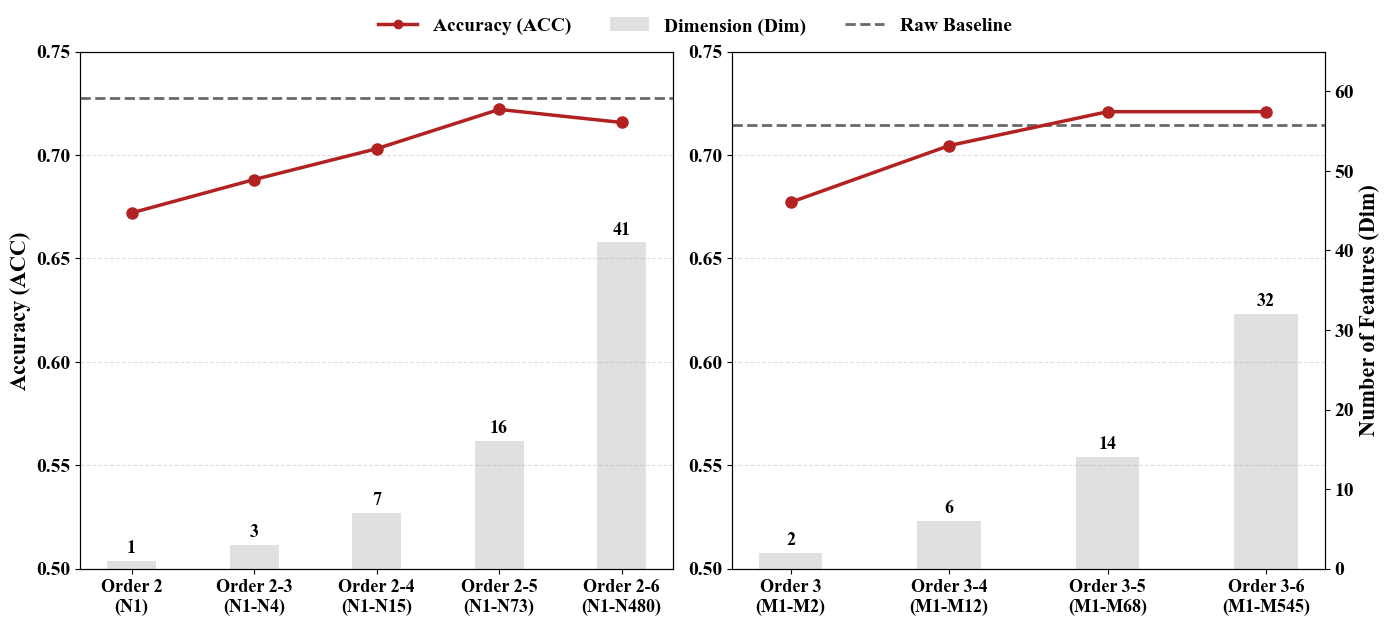

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

n_labels = ['Order 2\n(N1)', 'Order 2-3\n(N1-N4)', 'Order 2-4\n(N1-N15)', 'Order 2-5\n(N1-N73)', 'Order 2-6\n(N1-N480)']
n_dims = [1, 3, 7, 16, 41]
n_acc = [0.6720, 0.6881, 0.7030, 0.7220, 0.7157]
n_std = [0.0899, 0.1037, 0.1005, 0.0770, 0.0812]

m_labels = ['Order 3\n(M1-M2)', 'Order 3-4\n(M1-M12)', 'Order 3-5\n(M1-M68)', 'Order 3-6\n(M1-M545)']
m_dims = [2, 6, 14, 32]
m_acc = [0.6771, 0.7045, 0.7209, 0.7209]
m_std = [0.1026, 0.0912, 0.0765, 0.0818]
groups = [
    (n_labels, n_acc, n_std, n_dims, '(a) Node Orbit Features (N)'),
    (m_labels, m_acc, m_std, m_dims, '(b) Edge/Motif Orbit Features (M)')
]

baselines = [0.7274, 0.7146]
baseline_labels = ['Raw Baseline All (N1-N480): 0.7223', 'Raw Baseline All (M1-M545): 0.7103']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

PERF_YLIM = (0.50, 0.75)
FEAT_YLIM = (0, 65)

for i, ax1 in enumerate(axes):
    labels, means, stds, feats, title = groups[i]
    x_pos = np.arange(len(labels))

    ax2 = ax1.twinx()
    bars = ax2.bar(x_pos, feats, color='lightgray', alpha=0.7, width=0.4)
    ax2.set_ylim(FEAT_YLIM)

    for tick in ax2.get_yticklabels():
        tick.set_fontname('Times New Roman')
        tick.set_fontsize(14)
        tick.set_fontweight('bold')
        
    if i == 1:
        ax2.set_ylabel('Number of Features (Dim)', fontsize=16, fontweight='bold', fontname='Times New Roman')
    else:
        ax2.set_yticklabels([]) 
        ax2.tick_params(axis='y', length=0)

    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)
    
    line = ax1.errorbar(x_pos, means, yerr=None, fmt='-o', color='#B22222', 
                        ecolor='black', elinewidth=1.5, capsize=5, markersize=8, 
                        linewidth=2.5)

    baseline_y = baselines[i]
    ax1.axhline(y=baseline_y, color='dimgray', linestyle='--', linewidth=2, zorder=0)
    


    ax1.set_ylim(PERF_YLIM)

    for tick in ax1.get_yticklabels():
        tick.set_fontname('Times New Roman')
        tick.set_fontsize(14)
        tick.set_fontweight('bold')
        
    if i == 0:
        ax1.set_ylabel('Accuracy (ACC)', fontsize=16, fontweight='bold', fontname='Times New Roman')

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, fontsize=13, fontweight='bold', fontname='Times New Roman')
    # ax1.set_title(title, fontsize=16, fontweight='bold', fontname='Times New Roman', pad=15)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.4)

    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  
                     textcoords="offset points",
                     ha='center', va='bottom', 
                     fontsize=13, fontweight='bold', fontname='Times New Roman')

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
custom_lines = [
    Line2D([0], [0], color='#B22222', marker='o', lw=2.5, label='Accuracy (ACC)'),
    Patch(facecolor='lightgray', alpha=0.7, label='Dimension (Dim)'),
    Line2D([0], [0], color='dimgray', linestyle='--', lw=2, label='Raw Baseline') 
]

fig.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, 
           prop={'family': 'Times New Roman', 'size': 14, 'weight': 'bold'}, frameon=False)

plt.tight_layout()
plt.show()